In [56]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from skimage.morphology import remove_small_objects

import kagglehub

In [57]:
path = kagglehub.dataset_download(
    "mahmudulhasantasin/data-science-bowl-2018-competition-merged-mask"
)

DATASET_PATH = f"{path}/data science bowl 2018/stage1_train 2"
print("Dataset path:", DATASET_PATH)

Dataset path: /kaggle/input/data-science-bowl-2018-competition-merged-mask/data science bowl 2018/stage1_train 2


In [58]:
def create_binary_mask(mask_folder, shape):
    combined = np.zeros(shape, dtype=np.uint8)

    for mfile in os.listdir(mask_folder):
        mask = cv2.imread(os.path.join(mask_folder, mfile), 0)
        if mask is not None:
            combined = np.logical_or(combined, mask)

    return combined.astype(np.uint8)


In [59]:
def naive_watershed(binary_mask):

    dist = distance_transform_edt(binary_mask)
    labels = watershed(-dist, mask=binary_mask)

    return labels


In [60]:
def controlled_watershed(binary_mask, footprint_size):

    dist = distance_transform_edt(binary_mask)

    local_max = peak_local_max(
        dist,
        footprint=np.ones((footprint_size, footprint_size)),
        labels=binary_mask
    )

    marker_mask = np.zeros(dist.shape, dtype=bool)
    marker_mask[tuple(local_max.T)] = True

    markers = label(marker_mask)

    labels = watershed(-dist, markers=markers, mask=binary_mask)

    return labels


Image 1
Ground Truth: 28
Naive: 43
Controlled: 27


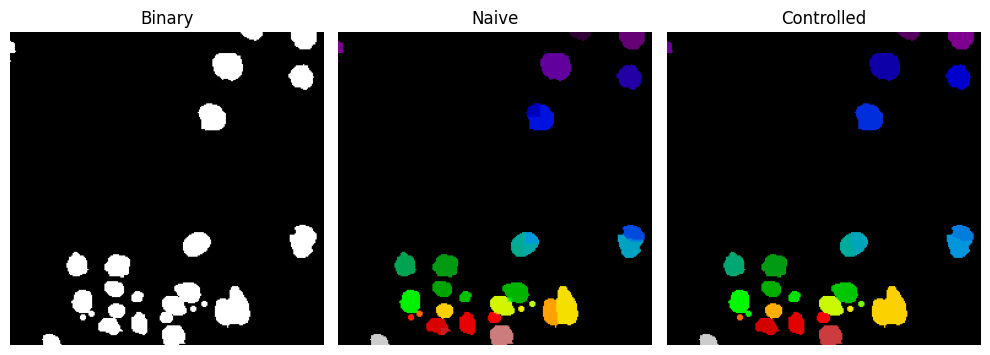


Image 2
Ground Truth: 37
Naive: 68
Controlled: 39


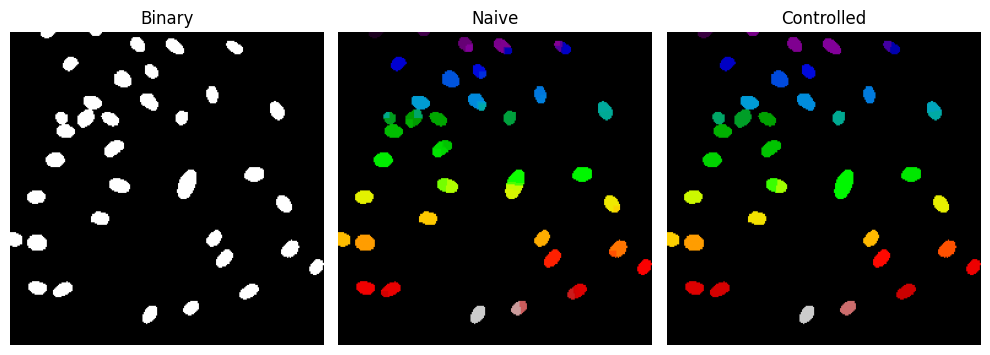


Image 3
Ground Truth: 71
Naive: 262
Controlled: 86


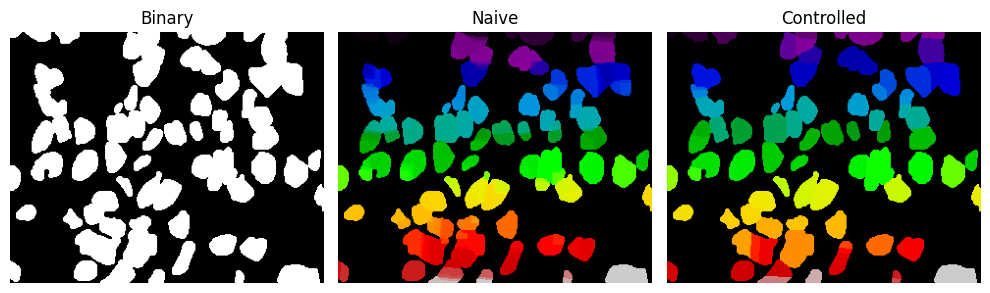


Image 4
Ground Truth: 87
Naive: 181
Controlled: 102


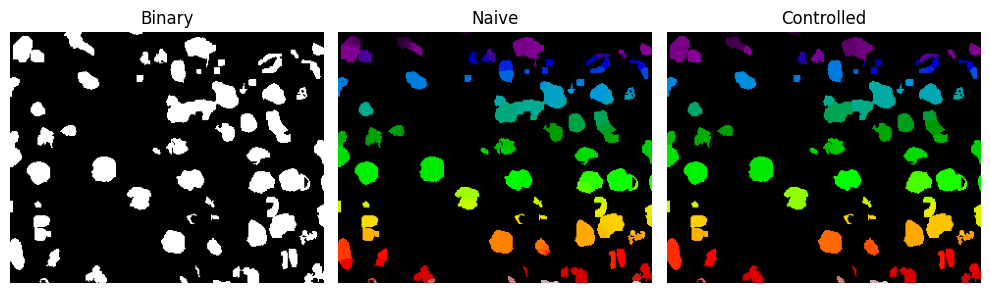


Image 5
Ground Truth: 8
Naive: 41
Controlled: 12


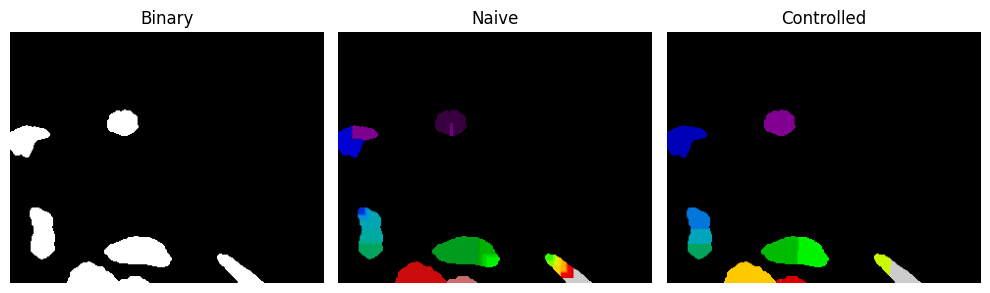

In [62]:
MAX_IMAGES = 5
processed = 0

folders = sorted(os.listdir(DATASET_PATH))

for folder in folders:

    if processed >= MAX_IMAGES:
        break

    sample_path = os.path.join(DATASET_PATH, folder)
    img_dir = os.path.join(sample_path, "images")
    mask_dir = os.path.join(sample_path, "masks")

    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        continue

    image_file = os.listdir(img_dir)[0]
    image = cv2.imread(os.path.join(img_dir, image_file))

    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    binary_mask = create_binary_mask(mask_dir, gray.shape)

    gt_count = len(os.listdir(mask_dir))
    distance = distance_transform_edt(binary_mask)

    naive_labels = naive_watershed(binary_mask)
    controlled_labels = controlled_watershed(binary_mask, 10)
    print(f"\nImage {processed+1}")
    print("Ground Truth:", gt_count)
    print("Naive:", naive_labels.max())
    print("Controlled:", controlled_labels.max())

    
    plt.figure(figsize=(10,6))

    plt.subplot(1,3,1)
    plt.imshow(binary_mask, cmap='gray')
    plt.title("Binary")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(naive_labels, cmap='nipy_spectral')
    plt.title("Naive")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(controlled_labels, cmap='nipy_spectral')
    plt.title("Controlled")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    processed += 1
    